### Section I Categorical to Numerical Conversion


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
#Load the Titanic dataset 
ds=pd.read_csv("titanic_train_imputed.csv")


In [8]:
ds

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone,survived
0,3,male,28.5,0,0,56.4958,S,Third,man,True,C,Southampton,True,1
1,2,male,28.5,0,0,0.0000,S,Second,man,True,C,Southampton,True,0
2,1,male,28.5,0,0,221.7792,S,First,man,True,C,Southampton,True,0
3,3,female,18.0,0,1,9.3500,S,Third,woman,False,C,Southampton,False,1
4,2,female,31.0,1,1,26.2500,S,Second,woman,False,C,Southampton,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,3,female,28.5,0,0,7.8792,Q,Third,woman,False,C,Queenstown,True,1
708,1,female,35.0,0,0,512.3292,C,First,woman,False,C,Cherbourg,True,1
709,3,female,48.0,1,3,34.3750,S,Third,woman,False,C,Southampton,False,0
710,1,male,47.0,0,0,38.5000,S,First,man,True,E,Southampton,True,0


In [10]:

# Q2. Separate the target column

x=ds.iloc[ : , :-1]
y=ds.iloc[ : ,-1]


In [11]:
# Display the input features
x

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,3,male,28.5,0,0,56.4958,S,Third,man,True,C,Southampton,True
1,2,male,28.5,0,0,0.0000,S,Second,man,True,C,Southampton,True
2,1,male,28.5,0,0,221.7792,S,First,man,True,C,Southampton,True
3,3,female,18.0,0,1,9.3500,S,Third,woman,False,C,Southampton,False
4,2,female,31.0,1,1,26.2500,S,Second,woman,False,C,Southampton,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,3,female,28.5,0,0,7.8792,Q,Third,woman,False,C,Queenstown,True
708,1,female,35.0,0,0,512.3292,C,First,woman,False,C,Cherbourg,True
709,3,female,48.0,1,3,34.3750,S,Third,woman,False,C,Southampton,False
710,1,male,47.0,0,0,38.5000,S,First,man,True,E,Southampton,True


In [12]:
# Display the target column
y

0      1
1      0
2      0
3      1
4      1
      ..
707    1
708    1
709    0
710    0
711    1
Name: survived, Length: 712, dtype: int64

In [13]:
# Q3. Drop redundant columns

df=ds.drop(["who","embarked","adult_male","pclass"],axis=1) #droped calums that are  having redundancy

# Display the dataset after dropping redundant columns
df

,sex,age,sibsp,parch,fare,class,deck,embark_town,alone,survived
0,male,28.5,0,0,56.4958,Third,C,Southampton,True,1
1,male,28.5,0,0,0.0000,Second,C,Southampton,True,0
2,male,28.5,0,0,221.7792,First,C,Southampton,True,0
3,female,18.0,0,1,9.3500,Third,C,Southampton,False,1
4,female,31.0,1,1,26.2500,Second,C,Southampton,False,1
...,...,...,...,...,...,...,...,...,...,...
707,female,28.5,0,0,7.8792,Third,C,Queenstown,True,1
708,female,35.0,0,0,512.3292,First,C,Cherbourg,True,1
709,female,48.0,1,3,34.3750,Third,C,Southampton,False,0
710,male,47.0,0,0,38.5000,First,E,Southampton,True,0


In [14]:
# Q4. Identify the categorical columns

df.info() #categorical valued columns are in strg datatype.

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          712 non-null    str    
 1   age          712 non-null    float64
 2   sibsp        712 non-null    int64  
 3   parch        712 non-null    int64  
 4   fare         712 non-null    float64
 5   class        712 non-null    str    
 6   deck         712 non-null    str    
 7   embark_town  712 non-null    str    
 8   alone        712 non-null    bool   
 9   survived     712 non-null    int64  
dtypes: bool(1), float64(2), int64(3), str(4)
memory usage: 50.9 KB


In [15]:
# Q5. Apply Label Encoding for ordinal categories

# Applying Label Encoding for ordinal categories.
# The ordinal category is the class column.

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['First','Second','Third']])

df['class'] = encoder.fit_transform(df[['class']])



In [16]:
# Display the encoded dataset
df

,sex,age,sibsp,parch,fare,class,deck,embark_town,alone,survived
0,male,28.5,0,0,56.4958,2.0,C,Southampton,True,1
1,male,28.5,0,0,0.0000,1.0,C,Southampton,True,0
2,male,28.5,0,0,221.7792,0.0,C,Southampton,True,0
3,female,18.0,0,1,9.3500,2.0,C,Southampton,False,1
4,female,31.0,1,1,26.2500,1.0,C,Southampton,False,1
...,...,...,...,...,...,...,...,...,...,...
707,female,28.5,0,0,7.8792,2.0,C,Queenstown,True,1
708,female,35.0,0,0,512.3292,0.0,C,Cherbourg,True,1
709,female,48.0,1,3,34.3750,2.0,C,Southampton,False,0
710,male,47.0,0,0,38.5000,0.0,E,Southampton,True,0


In [17]:
# Q6. Apply One-Hot Encoding for nominal categories

clms=["sex","deck","embark_town"]
dff=pd.get_dummies(df,columns=clms,dtype=int,drop_first=True)



In [18]:
# Display the encoded dataset
dff

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0,0,56.4958,2.0,True,1,1,0,1,0,0,0,0,0,1
1,28.5,0,0,0.0000,1.0,True,0,1,0,1,0,0,0,0,0,1
2,28.5,0,0,221.7792,0.0,True,0,1,0,1,0,0,0,0,0,1
3,18.0,0,1,9.3500,2.0,False,1,0,0,1,0,0,0,0,0,1
4,31.0,1,1,26.2500,1.0,False,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0,0,7.8792,2.0,True,1,0,0,1,0,0,0,0,1,0
708,35.0,0,0,512.3292,0.0,True,1,0,0,1,0,0,0,0,0,0
709,48.0,1,3,34.3750,2.0,False,0,0,0,1,0,0,0,0,0,1
710,47.0,0,0,38.5000,0.0,True,0,1,0,0,0,1,0,0,0,1


In [19]:
# Q7. Apply binary encoding to the 'alone' column

# Done binary encoding for "alone" column
dff['alone'] = dff['alone'].astype(int)



In [20]:
# Display the final numerical and encoded features
dff

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0,0,56.4958,2.0,1,1,1,0,1,0,0,0,0,0,1
1,28.5,0,0,0.0000,1.0,1,0,1,0,1,0,0,0,0,0,1
2,28.5,0,0,221.7792,0.0,1,0,1,0,1,0,0,0,0,0,1
3,18.0,0,1,9.3500,2.0,0,1,0,0,1,0,0,0,0,0,1
4,31.0,1,1,26.2500,1.0,0,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0,0,7.8792,2.0,1,1,0,0,1,0,0,0,0,1,0
708,35.0,0,0,512.3292,0.0,1,1,0,0,1,0,0,0,0,0,0
709,48.0,1,3,34.3750,2.0,0,0,0,0,1,0,0,0,0,0,1
710,47.0,0,0,38.5000,0.0,1,0,1,0,0,0,1,0,0,0,1


In [21]:
# Q8. Save the encoded dataset

# Saved the encoded dataset to CSV file named "Encoded_dataset"
dff.to_csv("Encoded_dataset.csv", index=False)

### SECTION II — OUTLIER ANALYSIS

In [22]:
# Q1. Load the encoded dataset from Section 1

dataset=pd.read_csv("Encoded_dataset.csv")

# Display the dataset
dataset

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0,0,56.4958,2.0,1,1,1,0,1,0,0,0,0,0,1
1,28.5,0,0,0.0000,1.0,1,0,1,0,1,0,0,0,0,0,1
2,28.5,0,0,221.7792,0.0,1,0,1,0,1,0,0,0,0,0,1
3,18.0,0,1,9.3500,2.0,0,1,0,0,1,0,0,0,0,0,1
4,31.0,1,1,26.2500,1.0,0,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0,0,7.8792,2.0,1,1,0,0,1,0,0,0,0,1,0
708,35.0,0,0,512.3292,0.0,1,1,0,0,1,0,0,0,0,0,0
709,48.0,1,3,34.3750,2.0,0,0,0,0,1,0,0,0,0,0,1
710,47.0,0,0,38.5000,0.0,1,0,1,0,0,0,1,0,0,0,1


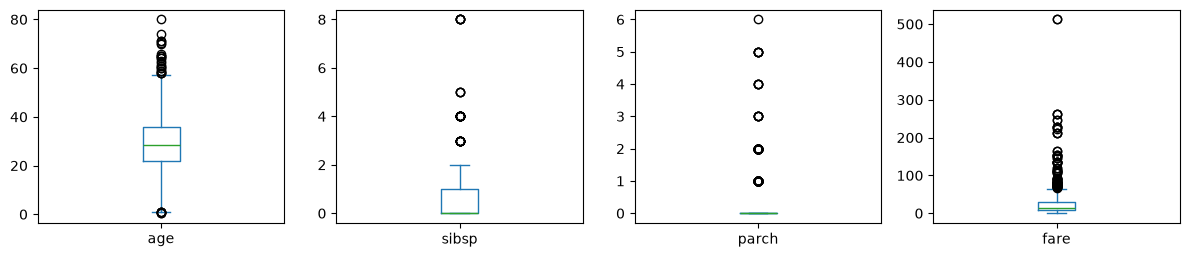

In [24]:
# Q2. Plot boxplots for numerical features

dataset[['age','sibsp','parch','fare']].plot(kind="box",subplots=True,layout=(4,4),figsize=(12,10))

plt.tight_layout()

In [25]:
# Q3. Calculate the IQR bounds for each numerical column

# Here the numerical columns "age", "sibsp", "parch", "fare"
# are taken into a list and then in a for loop each column
# will be treated as a series.
#
# It will calculate quantile 1 and 3, after that calculate IQR.
# According to IQR it takes appropriate lower and upper bound.
#
# For making the steps easier we are using a for loop,
# so there is no need to write code for each column separately.

columns = ['age','sibsp','parch','fare']

for col in columns:
    series = dataset[col]
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print("\nColumn:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower:", lower)
    print("Upper:", upper)


Column: age
Q1: 22.0
Q3: 36.0
IQR: 14.0
Lower: 1.0
Upper: 57.0

Column: sibsp
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower: -1.5
Upper: 2.5

Column: parch
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower: 0.0
Upper: 0.0

Column: fare
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower: -26.7605
Upper: 65.6563


In [28]:
# Q4. Cap outliers on the numerical columns

# Outliers are capped using the lower and upper IQR boundaries.

for col in columns:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    dataset[col] = dataset[col].clip(lower=lower,upper=upper)

dataset

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0.0,0,56.4958,2.0,1,1,1,0,1,0,0,0,0,0,1
1,28.5,0.0,0,0.0000,1.0,1,0,1,0,1,0,0,0,0,0,1
2,28.5,0.0,0,65.6563,0.0,1,0,1,0,1,0,0,0,0,0,1
3,18.0,0.0,0,9.3500,2.0,0,1,0,0,1,0,0,0,0,0,1
4,31.0,1.0,0,26.2500,1.0,0,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0.0,0,7.8792,2.0,1,1,0,0,1,0,0,0,0,1,0
708,35.0,0.0,0,65.6563,0.0,1,1,0,0,1,0,0,0,0,0,0
709,48.0,1.0,0,34.3750,2.0,0,0,0,0,1,0,0,0,0,0,1
710,47.0,0.0,0,38.5000,0.0,1,0,1,0,0,0,1,0,0,0,1


In [29]:
# Q5. Save the outlier-treated dataset

dataset.to_csv("outlier_treated_dataset.csv",index=False)

print("saved successfully.")

saved successfully.


### SECTION III — CLASS IMBALANCE

In [30]:
# Q1. Load the Diabetes dataset

dataset = pd.read_csv("diabetes.csv")
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [31]:
# Q2. Separate the features and target column

x = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [32]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [33]:
# Q3. Check the target class distribution

print(dataset['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


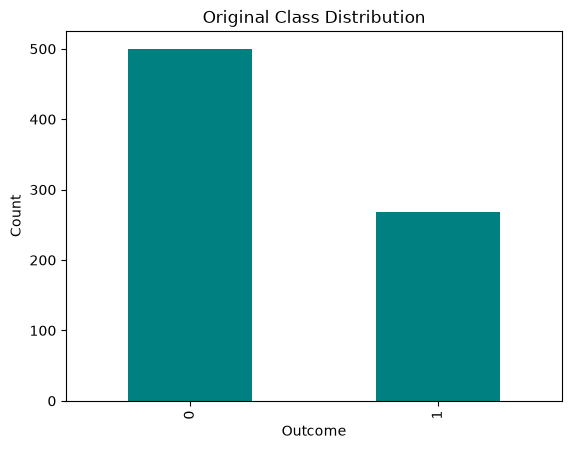

In [44]:

# Q4. Plot the original class distribution

dataset['Outcome'].value_counts().plot(kind='bar',color='teal')

plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Original Class Distribution')
plt.show()

In [37]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# Q5. Apply Under-Sampling

# Under-sampling reduces the majority class.

from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
Xunder, yunder = under_sampler.fit_resample(x, y)
print(yunder.value_counts())

Outcome
0    268
1    268
Name: count, dtype: int64


In [41]:
# Q6. Apply Over-Sampling

# Over-sampling increases the minority class
# by adding duplicate samples.

from imblearn.over_sampling import RandomOverSampler
oversampler = RandomOverSampler(random_state=42)
Xover, yover = oversampler.fit_resample(x, y)

print(yover.value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


In [42]:
# Q7. Apply SMOTE

# SMOTE creates synthetic samples for the minority class.

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
Xsmote, ysmote = smote.fit_resample(x, y)
print(ysmote.value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


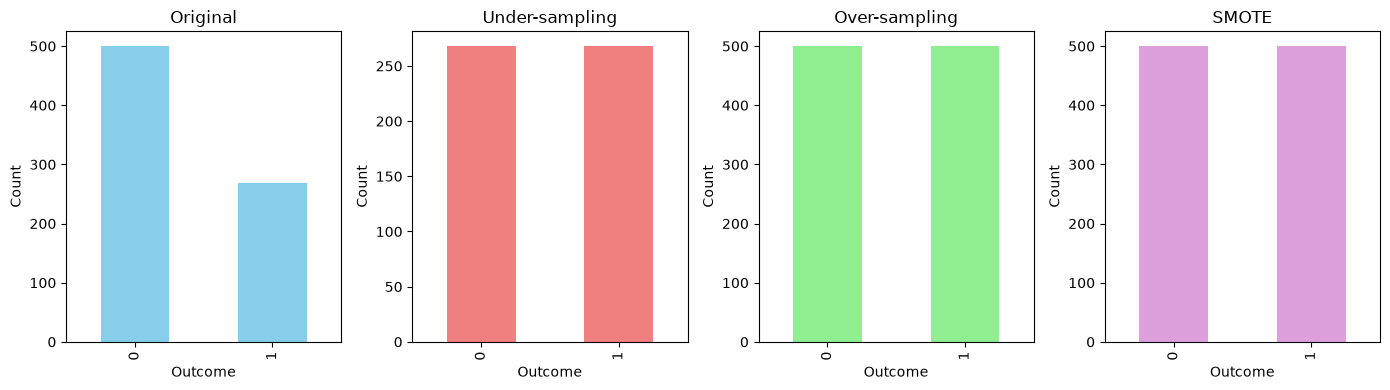

In [48]:
# Q8. Compare class distributions before and after sampling 
 
distributions = { 'Original': y.value_counts(), 'Under-sampling': yunder.value_counts(), 'Over-sampling': yover.value_counts(), 'SMOTE': ysmote.value_counts() } 
 
fig, axes = plt.subplots(1, 4, figsize=(14, 4)) 

colors = ['skyblue', 'lightcoral', 'lightgreen', 'plum']
 
for ax, (name, counts), color in zip(axes, distributions.items(), colors): 
    counts.sort_index().plot(kind='bar',ax=ax,color=color) 
 
    ax.set_title(name) 
    ax.set_xlabel('Outcome') 
    ax.set_ylabel('Count') 
 
plt.tight_layout() 
plt.show()

### SECTION IV — FULL DATA PREPROCESSING PROJECT

### Step 1: Loading & Cleaning

In [49]:
# Q1. Load the Loan Approval dataset

loan_data = pd.read_csv("loan.csv")
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [50]:

loan_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [51]:
# Check unique values in Dependents

loan_data['Dependents'].unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [54]:
# Q5. Replace '3+' with '3'

loan_data['Dependents'] = loan_data['Dependents'].replace('3+', '3')

In [56]:
# Q6. Convert Dependents into numerical form

loan_data["Dependents"] = loan_data["Dependents"].astype(float)
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [57]:
#  Check for duplicate rows

loan_data.duplicated().sum()

np.int64(0)

In [58]:
#  Check missing values

loan_data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [59]:
# Q9. Handle missing values

# Fill categorical columns using mode

loan_data['Gender'] = loan_data['Gender'].fillna(loan_data['Gender'].mode()[0])

loan_data['Married'] = loan_data['Married'].fillna(loan_data['Married'].mode()[0])

loan_data['Dependents'] = loan_data['Dependents'].fillna(loan_data['Dependents'].mode()[0])

loan_data['Self_Employed'] = loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0])

# Fill numerical columns using median

loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median())

loan_data['Loan_Amount_Term'] = loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].median())

# Credit_History is binary/categorical,
# so mode is used.

loan_data['Credit_History'] = loan_data['Credit_History'].fillna(loan_data['Credit_History'].mode()[0])

In [60]:
# Check missing values after treatment

loan_data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [64]:
#Identify numerical columns for outlier treatment

outlier_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

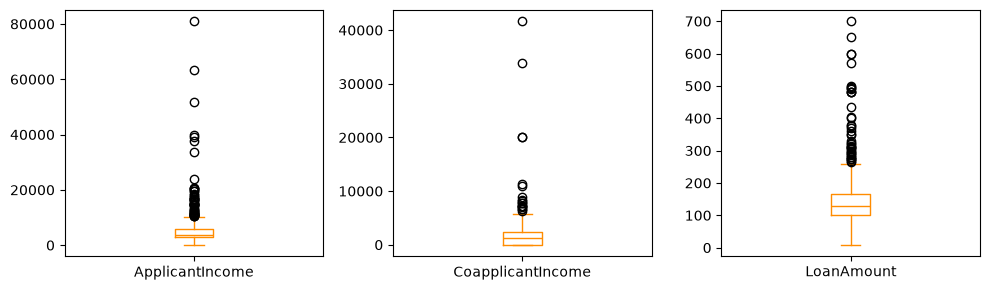

In [65]:
# Plot boxplots for numerical features

loan_data[
    ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]].plot(kind="box",subplots=True,layout=(1, 3),figsize=(10, 3),color='darkorange')
plt.tight_layout()

In [66]:
#  Calculate IQR bounds for ApplicantIncome

Q1 = loan_data['ApplicantIncome'].quantile(0.25)
Q3 = loan_data['ApplicantIncome'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: -1498.75
Upper: 10171.25


In [67]:
# Q15. Count ApplicantIncome outliers

print("Outliers above upper bound:",len(loan_data[loan_data["ApplicantIncome"] > upper_bound]))

print("Outliers below lower bound:",len(loan_data[loan_data["ApplicantIncome"] < lower_bound]))

Outliers above upper bound: 50
Outliers below lower bound: 0


In [68]:
#  Cap ApplicantIncome outliers

loan_data['ApplicantIncome'] = loan_data[
    'ApplicantIncome'
].clip(
    lower_bound,
    upper_bound
)

In [69]:
#  Calculate IQR bounds for CoapplicantIncome

Q1 = loan_data['CoapplicantIncome'].quantile(0.25)
Q3 = loan_data['CoapplicantIncome'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: -3445.875
Upper: 5743.125


In [71]:
# Q18. Count CoapplicantIncome outliers

print("Outliers above upper bound:",len(loan_data[loan_data["CoapplicantIncome"] > upper_bound]))

print("Outliers below lower bound:",len(loan_data[loan_data["CoapplicantIncome"] < lower_bound]))

Outliers above upper bound: 18
Outliers below lower bound: 0


In [72]:
#  Calculate IQR bounds for LoanAmount

Q1 = loan_data['LoanAmount'].quantile(0.25)
Q3 = loan_data['LoanAmount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: 3.5
Upper: 261.5


In [74]:
#  Count LoanAmount outliers

print("Outliers above upper bound:",len(loan_data[loan_data["LoanAmount"] > upper_bound ]))

print("Outliers below lower bound:",len(loan_data[loan_data["LoanAmount"] < lower_bound]))

Outliers above upper bound: 41
Outliers below lower bound: 0


In [75]:
# . Cap LoanAmount outliers

loan_data['LoanAmount'] = loan_data['LoanAmount'].clip(lower_bound,upper_bound)

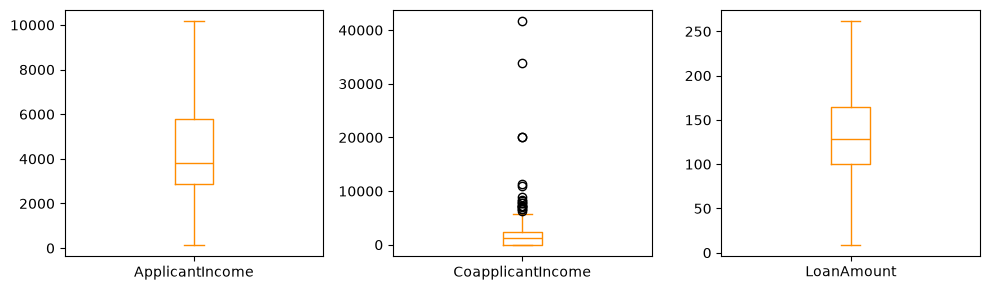

In [76]:
#  Verify outlier treatment using boxplots

loan_data[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]].plot(kind="box",subplots=True,layout=(1, 3),figsize=(10, 3),color='darkorange')

plt.tight_layout()

In [77]:
#  Encode binary categorical columns

loan_data['Gender'] = loan_data['Gender'].map({'Male': 1,'Female': 0})

loan_data['Married'] = loan_data['Married'].map({'Yes': 1,'No': 0})

loan_data['Education'] = loan_data['Education'].map({'Graduate': 1,'Not Graduate': 0})

loan_data['Self_Employed'] = loan_data['Self_Employed'].map({'Yes': 1,'No': 0})

In [78]:
#  Apply One-Hot Encoding to Property_Area

# Property_Area is a nominal categorical variable.

loan_data = pd.get_dummies(loan_data,columns=['Property_Area'],drop_first=True,dtype=int)

In [79]:
# Convert encoded Property_Area columns to integer

loan_data['Property_Area_Semiurban'] = loan_data['Property_Area_Semiurban'].astype(int)

loan_data['Property_Area_Urban'] = loan_data['Property_Area_Urban'].astype(int)

In [80]:
#Check the Loan_Status class distribution

loan_data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

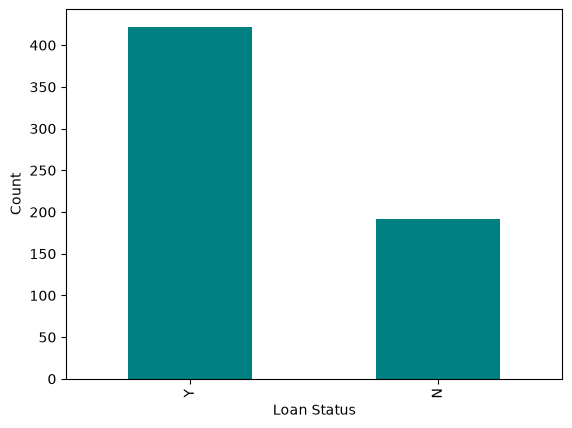

In [81]:
# Plot the Loan_Status class distribution

import matplotlib.pyplot as plt

loan_data['Loan_Status'].value_counts().plot(kind='bar',color='teal')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

In [82]:
# Separate features and target

loan_features = loan_data.drop(
    'Loan_Status',
    axis=1
)

loan_target = loan_data['Loan_Status']

In [83]:
loan_features

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849.0,0.0,128.0,360.0,1.0,0,1
1,1,1,1.0,1,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,1,1,3000.0,0.0,66.0,360.0,1.0,0,1
3,1,1,0.0,0,0,2583.0,2358.0,120.0,360.0,1.0,0,1
4,1,0,0.0,1,0,6000.0,0.0,141.0,360.0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,1,0,2900.0,0.0,71.0,360.0,1.0,0,0
610,1,1,3.0,1,0,4106.0,0.0,40.0,180.0,1.0,0,0
611,1,1,1.0,1,0,8072.0,240.0,253.0,360.0,1.0,0,1
612,1,1,2.0,1,0,7583.0,0.0,187.0,360.0,1.0,0,1


In [84]:
loan_target

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: str

In [85]:
# Q30. Split the data into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(loan_features,loan_target,test_size=0.2,random_state=42,stratify=loan_target)

In [86]:
# Q31. Apply SMOTE to the training data

from imblearn.over_sampling import SMOTE

smote_sampler = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = (smote_sampler.fit_resample(X_train,y_train))

In [87]:
#  Check class distribution after SMOTE

print(y_train_resampled.value_counts())

Loan_Status
Y    337
N    337
Name: count, dtype: int64


In [88]:
loan_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849.0,0.0,128.0,360.0,1.0,Y,0,1
1,1,1,1.0,1,0,4583.0,1508.0,128.0,360.0,1.0,N,0,0
2,1,1,0.0,1,1,3000.0,0.0,66.0,360.0,1.0,Y,0,1
3,1,1,0.0,0,0,2583.0,2358.0,120.0,360.0,1.0,Y,0,1
4,1,0,0.0,1,0,6000.0,0.0,141.0,360.0,1.0,Y,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,1,0,2900.0,0.0,71.0,360.0,1.0,Y,0,0
610,1,1,3.0,1,0,4106.0,0.0,40.0,180.0,1.0,Y,0,0
611,1,1,1.0,1,0,8072.0,240.0,253.0,360.0,1.0,Y,0,1
612,1,1,2.0,1,0,7583.0,0.0,187.0,360.0,1.0,Y,0,1


In [89]:
# Apply StandardScaler for feature scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data
# and transform the training data.

X_train_scaled = scaler.fit_transform(X_train_resampled)

# Use the same scaler to transform the test data.

X_test_scaled = scaler.transform( X_test)

In [90]:
X_train_scaled

array([[ 0.50278037, -1.28184915, -0.77087511, ...,  0.56575506,
        -0.6495698 ,  1.67568183],
       [ 0.50278037,  0.78012299,  0.27093913, ...,  0.56575506,
         1.53948043, -0.596772  ],
       [ 0.50278037,  0.78012299,  1.31275337, ..., -1.98908633,
        -0.6495698 , -0.596772  ],
       ...,
       [-1.98894001, -1.28184915, -0.77087511, ..., -1.22138769,
        -0.6495698 , -0.596772  ],
       [ 0.50278037,  0.78012299, -0.62673689, ..., -1.63561612,
        -0.6495698 , -0.596772  ],
       [-1.98894001, -1.28184915, -0.77087511, ..., -1.98908633,
        -0.6495698 , -0.596772  ]], shape=(674, 12))

In [91]:
X_test_scaled 

array([[ 0.50278037, -1.28184915, -0.77087511, ..., -1.98908633,
        -0.6495698 , -0.596772  ],
       [-1.98894001,  0.78012299, -0.77087511, ...,  0.56575506,
         1.53948043, -0.596772  ],
       [ 0.50278037,  0.78012299, -0.77087511, ...,  0.56575506,
        -0.6495698 , -0.596772  ],
       ...,
       [ 0.50278037,  0.78012299,  2.35456761, ..., -1.98908633,
         1.53948043, -0.596772  ],
       [ 0.50278037, -1.28184915, -0.77087511, ...,  0.56575506,
        -0.6495698 , -0.596772  ],
       [ 0.50278037, -1.28184915,  0.27093913, ..., -1.98908633,
        -0.6495698 ,  1.67568183]], shape=(123, 12))